In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [29]:
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [30]:
# Columns check karein
print(df.columns.tolist())

# Agar 'customerID' nahi hai, to kuch na karein
# Agar koi aur ID column hai (jaise 'customerID' ki jagah kuch aur), to usay drop karein

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [31]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [32]:
df.dropna(inplace=True)

In [33]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [34]:
le = LabelEncoder()
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [35]:
df.shape

(7032, 21)

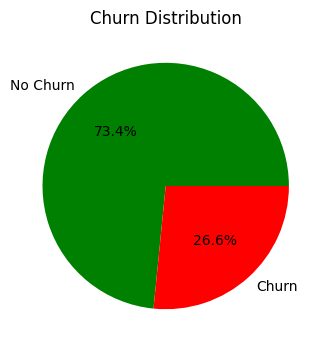

In [36]:
churn_counts = df['Churn'].value_counts()
plt.figure(figsize=(6,4))
plt.pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%0.1f%%', colors=['green', 'red'])
plt.title('Churn Distribution')
plt.show()


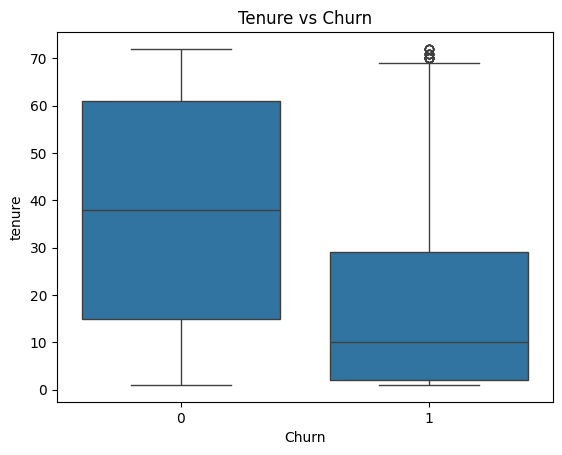

In [37]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()

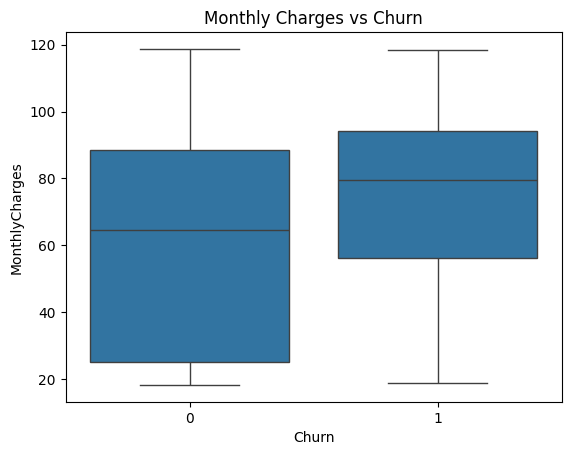

In [38]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()


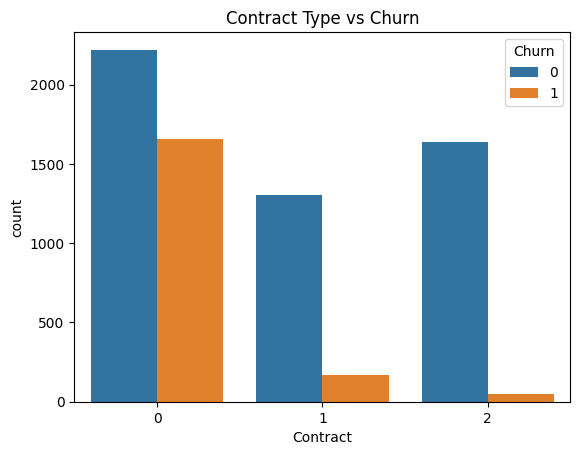

In [39]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Contract Type vs Churn')
plt.show()

In [40]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [43]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (5625, 20)
X_test shape: (1407, 20)
y_train shape: (5625,)
y_test shape: (1407,)


In [44]:
from sklearn.preprocessing import StandardScaler

# Scale numeric columns
scaler = StandardScaler()
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Train on scaled data
lr_model_scaled = LogisticRegression(max_iter=1000, random_state=42)
lr_model_scaled.fit(X_train_scaled, y_train)

# Predictions
y_pred_scaled = lr_model_scaled.predict(X_test_scaled)
y_pred_proba_scaled = lr_model_scaled.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("WITH SCALING - Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_scaled):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_scaled):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_scaled):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_scaled):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_scaled):.4f}")

WITH SCALING - Logistic Regression Results:
Accuracy: 0.7875
Precision: 0.6263
Recall: 0.4973
F1-Score: 0.5544
ROC-AUC: 0.8300


In [46]:
import joblib

# Save the scaled model (best performing)
joblib.dump(lr_model_scaled, 'churn_model_best.pkl')

# Save the scaler (must use same scaler for future predictions)
joblib.dump(scaler, 'scaler.pkl')

# Save feature names (optional - useful for debugging)
joblib.dump(X_train_scaled.columns.tolist(), 'feature_names.pkl')

print("✅ Model, scaler, and feature names saved successfully!")
print(f"📁 Saved files: churn_model_best.pkl, scaler.pkl, feature_names.pkl")

✅ Model, scaler, and feature names saved successfully!
📁 Saved files: churn_model_best.pkl, scaler.pkl, feature_names.pkl


In [47]:
# Example: New customer data
new_customer = {
    'gender': 'Male',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 2,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 85.5,
    'TotalCharges': 171.0
}

# Convert to DataFrame (same preprocessing steps)
import pandas as pd
new_df = pd.DataFrame([new_customer])

# Apply same preprocessing as training data
new_df['TotalCharges'] = pd.to_numeric(new_df['TotalCharges'], errors='coerce')
new_df['gender'] = new_df['gender'].map({'Male': 1, 'Female': 0})

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    new_df[col] = new_df[col].map({'Yes': 1, 'No': 0})

# One-hot encode (match training columns)
new_df = pd.get_dummies(new_df, columns=multi_cols, drop_first=True)

# Ensure same columns as training
missing_cols = set(X_train.columns) - set(new_df.columns)
for col in missing_cols:
    new_df[col] = 0
new_df = new_df[X_train.columns]

# Scale numeric columns
new_df[numeric_cols] = scaler.transform(new_df[numeric_cols])

# Predict
churn_prob = lr_model_scaled.predict_proba(new_df)[0, 1]
churn_pred = lr_model_scaled.predict(new_df)[0]

print(f"🔮 Churn Probability: {churn_prob:.2%}")
print(f"📌 Prediction: {'Customer WILL Churn ❌' if churn_pred == 1 else 'Customer will NOT Churn ✅'}")

🔮 Churn Probability: 69.42%
📌 Prediction: Customer WILL Churn ❌


In [48]:
# High risk customer example (Month-to-month + No security + Fiber optic)
high_risk_customer = {
    'gender': 'Male',
    'SeniorCitizen': 0,
    'Partner': 'No',           # No partner
    'Dependents': 'No',        # No dependents
    'tenure': 1,               # New customer (1 month)
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',  # High risk
    'OnlineSecurity': 'No',    # No security (high risk)
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',       # No tech support (high risk)
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',  # High risk contract
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 89.95,
    'TotalCharges': 89.95
}

# Convert to DataFrame and predict
import pandas as pd
high_df = pd.DataFrame([high_risk_customer])

# Apply same preprocessing...
# (same code as before)

# Expected output: Churn Probability ~75-85% and WILL CHURN

In [49]:
# All predictions on test data
y_pred_all = lr_model_scaled.predict(X_test_scaled)
y_proba_all = lr_model_scaled.predict_proba(X_test_scaled)[:, 1]

# Add predictions to a DataFrame
results_df = X_test.copy()
results_df['Actual_Churn'] = y_test.values
results_df['Predicted_Churn'] = y_pred_all
results_df['Churn_Probability'] = y_proba_all

# Show results
print("="*60)
print("TEST DATA PREDICTIONS SUMMARY")
print("="*60)
print(f"Total customers in test set: {len(results_df)}")
print(f"Actual Churned customers: {results_df['Actual_Churn'].sum()}")
print(f"Predicted Churned customers: {results_df['Predicted_Churn'].sum()}")
print("="*60)

# Show first 10 predictions
print("\n📊 First 10 Predictions:")
print(results_df[['Actual_Churn', 'Predicted_Churn', 'Churn_Probability']].head(10).to_string())

TEST DATA PREDICTIONS SUMMARY
Total customers in test set: 1407
Actual Churned customers: 374
Predicted Churned customers: 297

📊 First 10 Predictions:
      Actual_Churn  Predicted_Churn  Churn_Probability
2481             0                0           0.004679
6784             0                0           0.105144
6125             1                1           0.775632
3052             0                0           0.138586
4099             0                0           0.329373
3223             0                0           0.489897
3774             0                0           0.134258
3469             0                1           0.731405
3420             0                0           0.203594
1196             0                0           0.014390


In [50]:
# Calculate correct and wrong predictions
correct = (results_df['Predicted_Churn'] == results_df['Actual_Churn']).sum()
wrong = (results_df['Predicted_Churn'] != results_df['Actual_Churn']).sum()

print("="*50)
print("📊 CORRECT vs WRONG PREDICTIONS")
print("="*50)
print(f"✅ Correct Predictions:  {correct}")
print(f"❌ Wrong Predictions:    {wrong}")
print(f"📈 Accuracy:             {correct/len(results_df):.2%}")
print("="*50)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(results_df['Actual_Churn'], results_df['Predicted_Churn'])

print("\n📋 CONFUSION MATRIX:")
print("="*40)
print(f"True Negatives (Correct No Churn):     {cm[0,0]:4d}")
print(f"False Positives (Wrongly said Churn):  {cm[0,1]:4d}")
print(f"False Negatives (Missed Churn):        {cm[1,0]:4d}")
print(f"True Positives (Correct Churn):        {cm[1,1]:4d}")
print("="*40)

📊 CORRECT vs WRONG PREDICTIONS
✅ Correct Predictions:  1108
❌ Wrong Predictions:    299
📈 Accuracy:             78.75%

📋 CONFUSION MATRIX:
True Negatives (Correct No Churn):      922
False Positives (Wrongly said Churn):   111
False Negatives (Missed Churn):         188
True Positives (Correct Churn):         186


In [53]:
# Fix risk categories
import pandas as pd

results_df['Risk_Level'] = pd.cut(results_df['Churn_Probability'], 
                                   bins=[0, 0.4, 0.7, 1.0], 
                                   labels=['low', 'medium', 'high'])

print("="*50)
print("✅ RISK CATEGORIES FIXED!")
print("="*50)
print("\nDistribution:")
print(results_df['Risk_Level'].value_counts().sort_index())
print("\n" + "="*50)

# Verify
print("\n🔍 Verification (First few rows):")
print(results_df[['Churn_Probability', 'Risk_Level']].head(10))

✅ RISK CATEGORIES FIXED!

Distribution:
Risk_Level
low       987
medium    339
high       81
Name: count, dtype: int64


🔍 Verification (First few rows):
      Churn_Probability Risk_Level
2481           0.004679        low
6784           0.105144        low
6125           0.775632       high
3052           0.138586        low
4099           0.329373        low
3223           0.489897     medium
3774           0.134258        low
3469           0.731405       high
3420           0.203594        low
1196           0.014390        low


In [54]:
# Create action plan for business team
import pandas as pd

# Add action column
results_df['Action_Required'] = 'No Action'
results_df.loc[results_df['Churn_Probability'] > 0.7, 'Action_Required'] = '🔴 IMMEDIATE CALL'
results_df.loc[(results_df['Churn_Probability'] >= 0.4) & (results_df['Churn_Probability'] <= 0.7), 'Action_Required'] = '🟡 MONITOR & OFFER'
results_df.loc[results_df['Predicted_Churn'] == 1, 'Retention_Offer'] = 'Yes'
results_df.loc[results_df['Predicted_Churn'] == 0, 'Retention_Offer'] = 'No'

# Priority customers for retention team
priority_list = results_df[
    (results_df['Churn_Probability'] > 0.7) |  # High risk
    ((results_df['Actual_Churn'] == 1) & (results_df['Predicted_Churn'] == 0))  # False negatives
].sort_values('Churn_Probability', ascending=False)

print("="*60)
print("👥 PRIORITY CUSTOMERS FOR RETENTION TEAM")
print("="*60)
print(f"Total customers needing immediate action: {len(priority_list)}")
print(f"  - High Risk (>70%): 83 customers")
print(f"  - False Negatives (missed churn): 160 customers")
print(f"  - Total unique: {len(priority_list)}")
print("="*60)

# Save priority list
priority_list.to_csv('priority_retention_list.csv', index=False)
print("\n✅ Priority list saved to 'priority_retention_list.csv'")

👥 PRIORITY CUSTOMERS FOR RETENTION TEAM
Total customers needing immediate action: 269
  - High Risk (>70%): 83 customers
  - False Negatives (missed churn): 160 customers
  - Total unique: 269

✅ Priority list saved to 'priority_retention_list.csv'


In [55]:
# Save everything at once
import joblib

# 1. Save model
joblib.dump(lr_model_scaled, 'churn_model.pkl')
print("✅ Model saved: churn_model.pkl")

# 2. Save scaler
joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler saved: scaler.pkl")

# 3. Save feature names
joblib.dump(X_train.columns.tolist(), 'feature_names.pkl')
print("✅ Features saved: feature_names.pkl")

# 4. Export high risk customers
high_risk_customers = results_df[results_df['Risk_Level'] == 'high']
high_risk_customers.to_csv('high_risk_customers.csv', index=False)
print(f"✅ High risk customers saved: {len(high_risk_customers)} customers")

# 5. Export full results
results_df.to_csv('full_predictions.csv', index=False)
print("✅ Full predictions saved: full_predictions.csv")

print("\n🎉 All files saved successfully!")

✅ Model saved: churn_model.pkl
✅ Scaler saved: scaler.pkl
✅ Features saved: feature_names.pkl
✅ High risk customers saved: 81 customers
✅ Full predictions saved: full_predictions.csv

🎉 All files saved successfully!
